In [2]:
pip install pandas numpy matplotlib seaborn plotly


Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

<Figure size 1000x600 with 0 Axes>

In [16]:
fear_df = pd.read_csv("C:/Users/VAISHNAVI/crypto-sentiment-analysis/data/fear_greed_index.csv")
trade_df = pd.read_csv("C:/Users/VAISHNAVI/crypto-sentiment-analysis/data/historical_data.csv")

In [18]:
fear_df.head()
fear_df.info()
fear_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [20]:
trade_df.head()
trade_df.info()
trade_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [22]:
fear_df['date'] = pd.to_datetime(fear_df['date'])

trade_df['Timestamp IST'] = pd.to_datetime(
    trade_df['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

trade_df['date'] = trade_df['Timestamp IST'].dt.date
trade_df['date'] = pd.to_datetime(trade_df['date'])

In [24]:
fear_df.isnull().sum()
trade_df.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
dtype: int64

In [26]:
fear_df.drop_duplicates(inplace=True)
trade_df.drop_duplicates(inplace=True)

In [28]:
merged_df = pd.merge(
    trade_df,
    fear_df,
    on='date',
    how='inner'
)

In [30]:
print("Total Trades:", merged_df.shape[0])

Total Trades: 211218


In [32]:
merged_df['classification'].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

In [34]:
merged_df['Closed PnL'].describe()

count    211218.000000
mean         48.549304
std         917.989791
min     -117990.104100
25%           0.000000
50%           0.000000
75%           5.790132
max      135329.090100
Name: Closed PnL, dtype: float64

In [36]:
avg_pnl = merged_df.groupby('classification')['Closed PnL'].mean().sort_values()

print(avg_pnl)

classification
Neutral          34.307718
Extreme Fear     34.537862
Greed            42.743559
Fear             54.290400
Extreme Greed    67.892861
Name: Closed PnL, dtype: float64


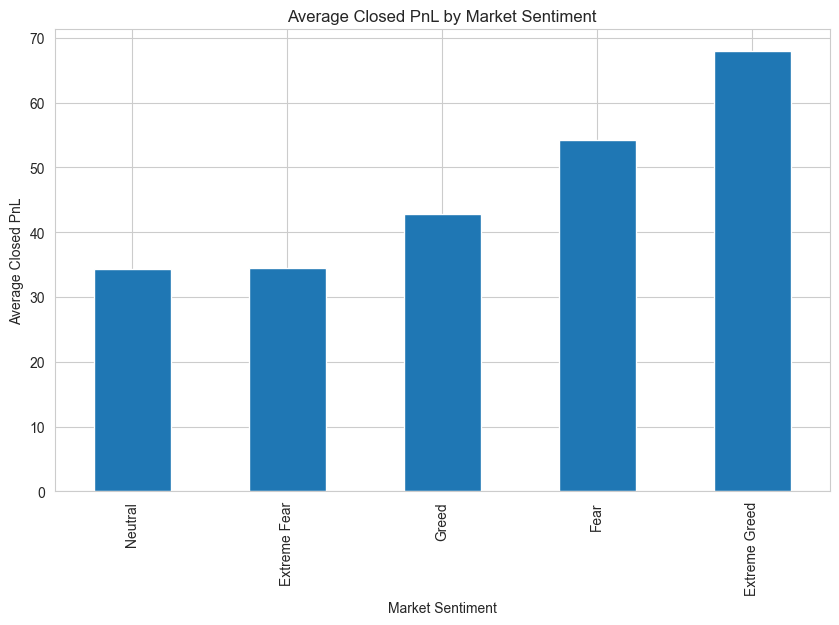

In [38]:
plt.figure(figsize=(10,6))
avg_pnl.plot(kind='bar')
plt.title('Average Closed PnL by Market Sentiment')
plt.ylabel('Average Closed PnL')
plt.xlabel('Market Sentiment')
plt.show()

In [40]:
trade_volume = merged_df.groupby('classification')['Size USD'].mean()

print(trade_volume)

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


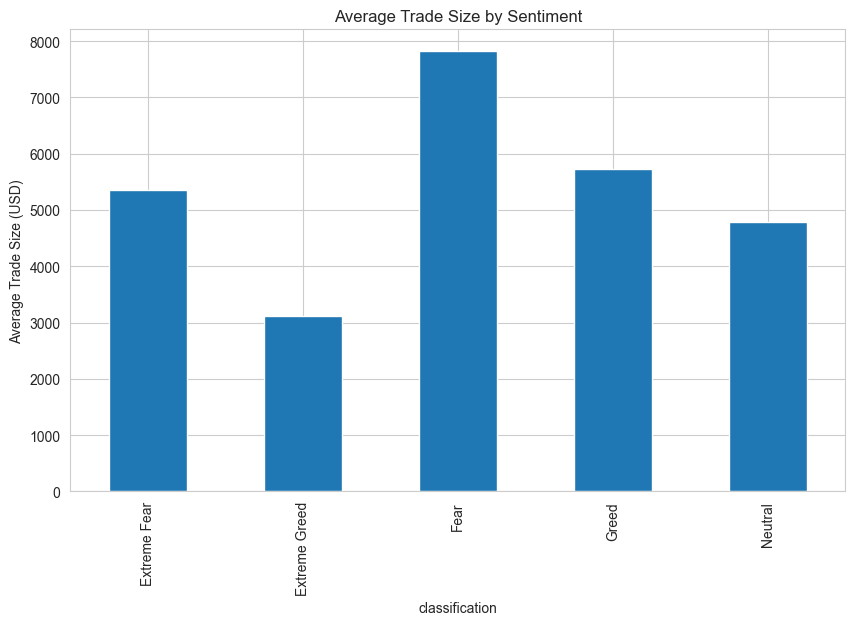

In [42]:
plt.figure(figsize=(10,6))
trade_volume.plot(kind='bar')
plt.title('Average Trade Size by Sentiment')
plt.ylabel('Average Trade Size (USD)')
plt.show()

In [44]:
side_analysis = pd.crosstab(
    merged_df['classification'],
    merged_df['Side']
)

print(side_analysis)

Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


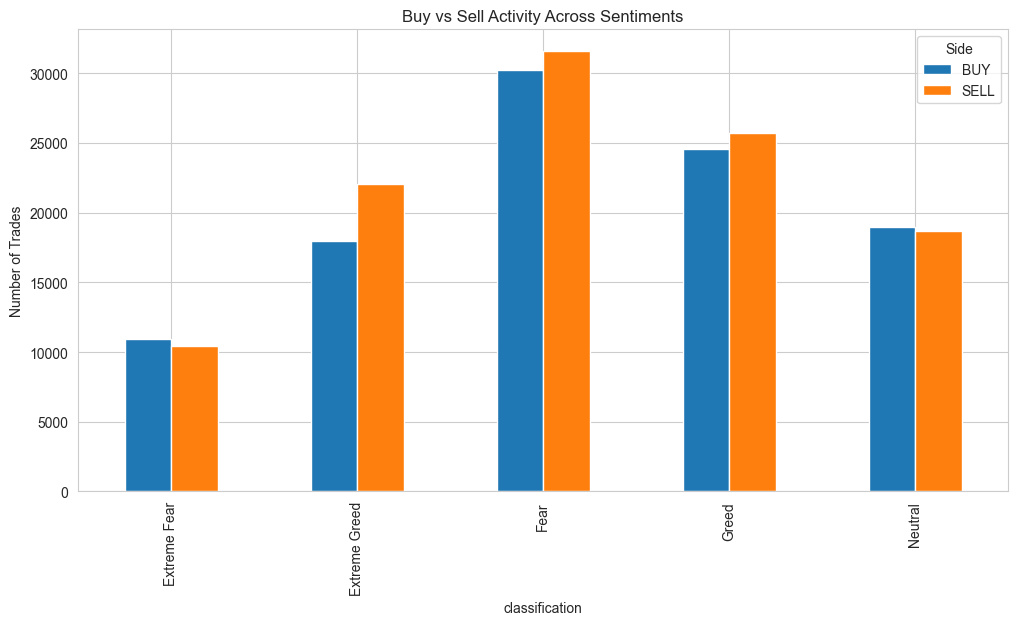

In [46]:
side_analysis.plot(kind='bar', figsize=(12,6))
plt.title('Buy vs Sell Activity Across Sentiments')
plt.ylabel('Number of Trades')
plt.show()

In [48]:
fee_analysis = merged_df.groupby('classification')['Fee'].mean()

print(fee_analysis)

classification
Extreme Fear     1.116291
Extreme Greed    0.675902
Fear             1.495172
Greed            1.254372
Neutral          1.044798
Name: Fee, dtype: float64


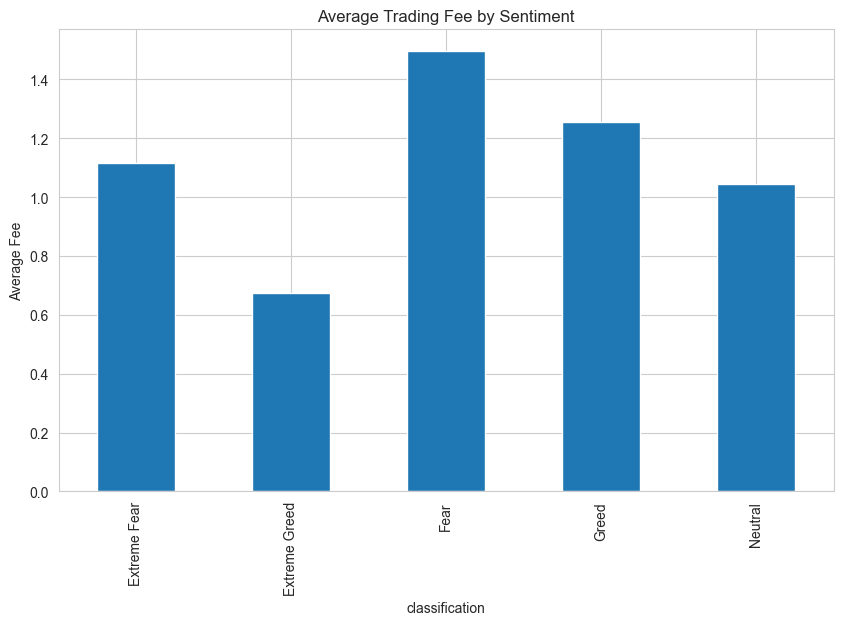

In [50]:
plt.figure(figsize=(10,6))
fee_analysis.plot(kind='bar')
plt.title('Average Trading Fee by Sentiment')
plt.ylabel('Average Fee')
plt.show()

In [52]:
coin_analysis = merged_df['Coin'].value_counts().head(10)

print(coin_analysis)

Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
Name: count, dtype: int64


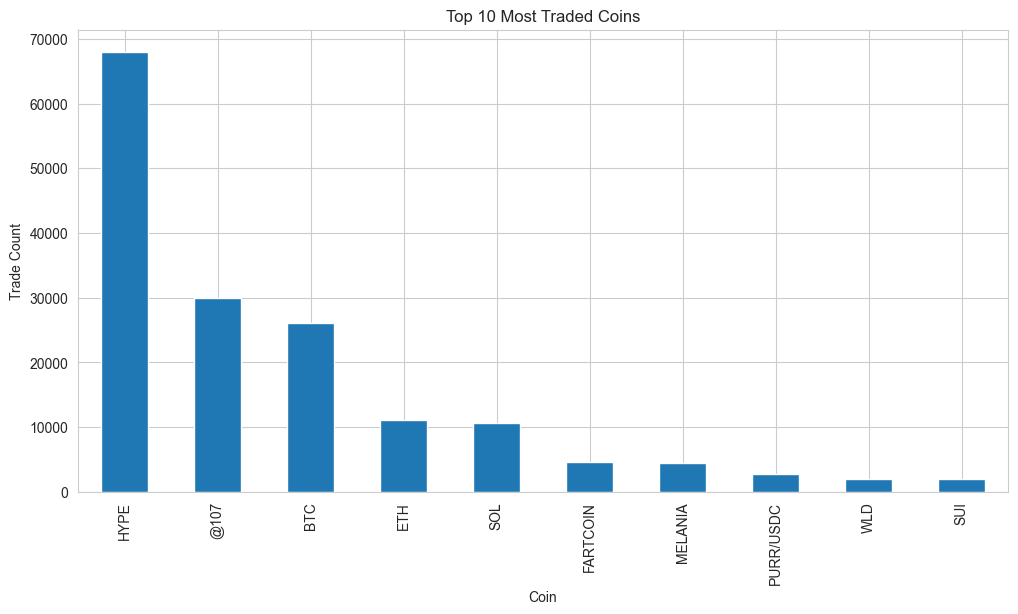

In [54]:
plt.figure(figsize=(12,6))
coin_analysis.plot(kind='bar')
plt.title('Top 10 Most Traded Coins')
plt.ylabel('Trade Count')
plt.show()

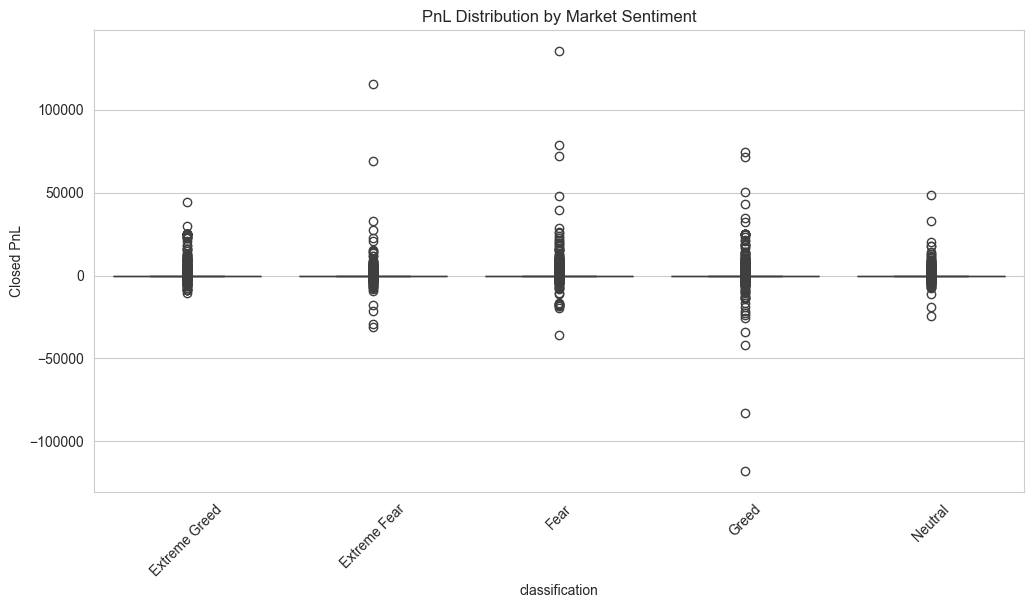

In [56]:
plt.figure(figsize=(12,6))
sns.boxplot(
    x='classification',
    y='Closed PnL',
    data=merged_df
)

plt.title('PnL Distribution by Market Sentiment')
plt.xticks(rotation=45)
plt.show()

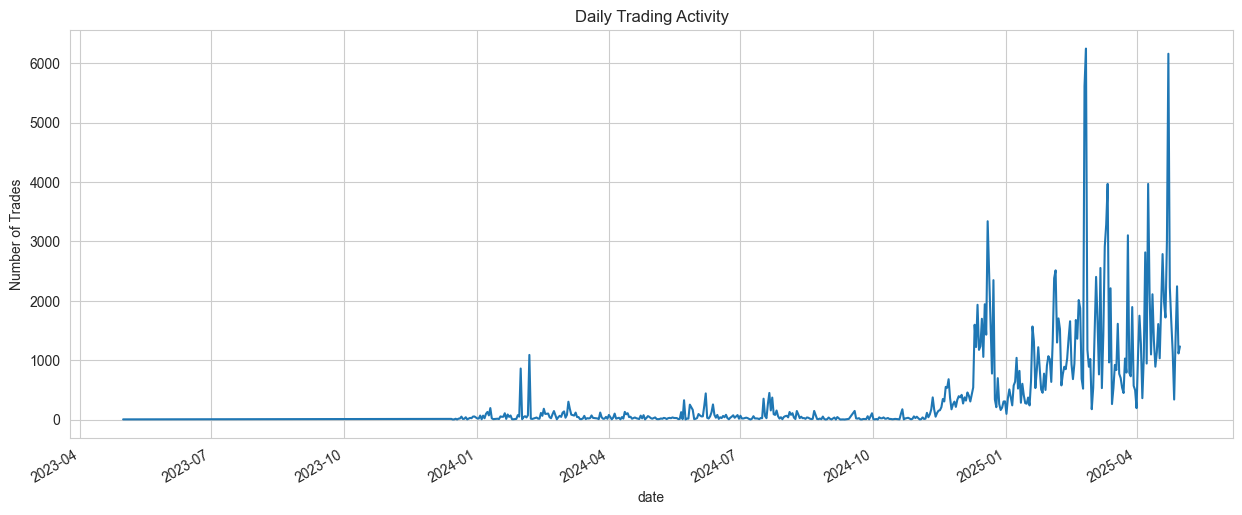

In [58]:
daily_activity = merged_df.groupby('date').size()

plt.figure(figsize=(15,6))
daily_activity.plot()
plt.title('Daily Trading Activity')
plt.ylabel('Number of Trades')
plt.show()

In [60]:
merged_df['is_profit'] = merged_df['Closed PnL'] > 0

In [62]:
win_rate = merged_df.groupby('classification')['is_profit'].mean() * 100

print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: is_profit, dtype: float64


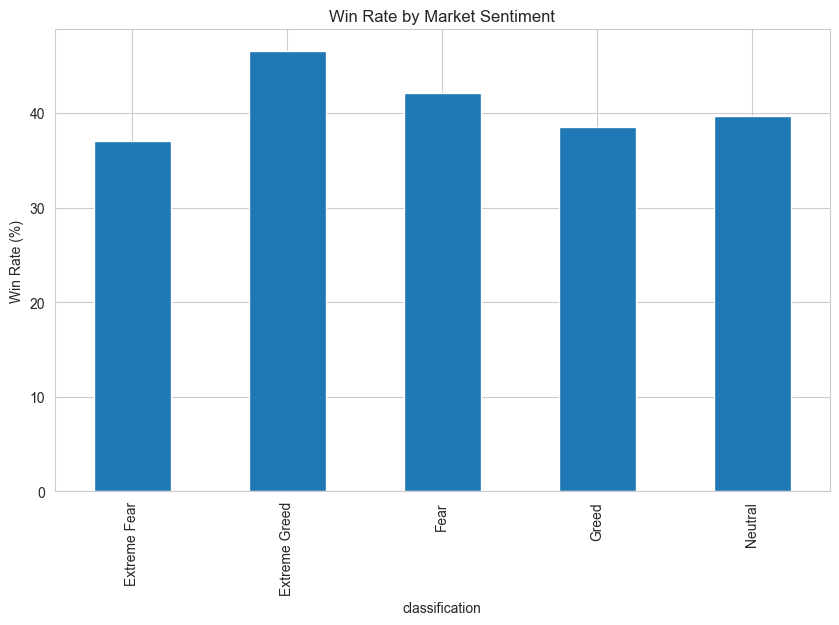

In [64]:
plt.figure(figsize=(10,6))
win_rate.plot(kind='bar')
plt.title('Win Rate by Market Sentiment')
plt.ylabel('Win Rate (%)')
plt.show()

In [66]:
top_traders = merged_df.groupby('Account')['Closed PnL'] \
    .sum() \
    .sort_values(ascending=False) \
    .head(10)

print(top_traders)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    3.605395e+05
Name: Closed PnL, dtype: float64


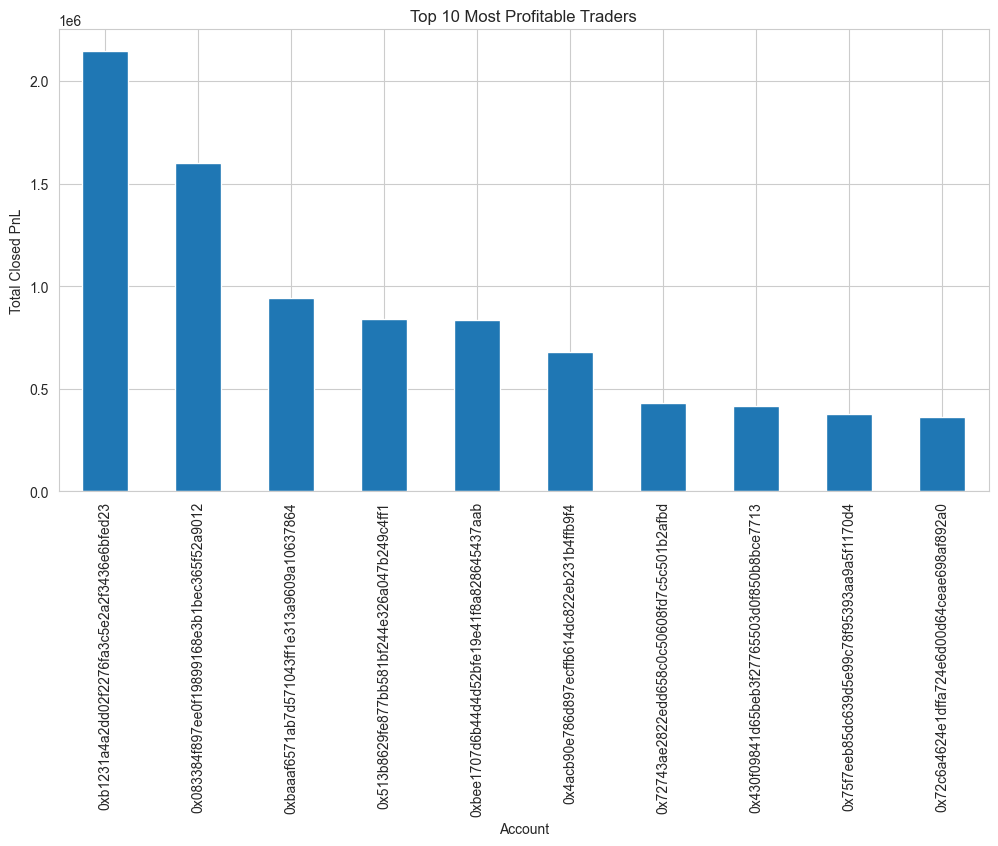

In [68]:
plt.figure(figsize=(12,6))
top_traders.plot(kind='bar')
plt.title('Top 10 Most Profitable Traders')
plt.ylabel('Total Closed PnL')
plt.show()

In [70]:
correlation_data = merged_df[[
    'Execution Price',
    'Size USD',
    'Closed PnL',
    'Fee',
    'value'
]]

corr_matrix = correlation_data.corr()

print(corr_matrix)

                 Execution Price  Size USD  Closed PnL       Fee     value
Execution Price         1.000000  0.189859   -0.006429  0.225266 -0.027558
Size USD                0.189859  1.000000    0.123645  0.745940 -0.029843
Closed PnL             -0.006429  0.123645    1.000000  0.084094  0.008121
Fee                     0.225266  0.745940    0.084094  1.000000 -0.026877
value                  -0.027558 -0.029843    0.008121 -0.026877  1.000000


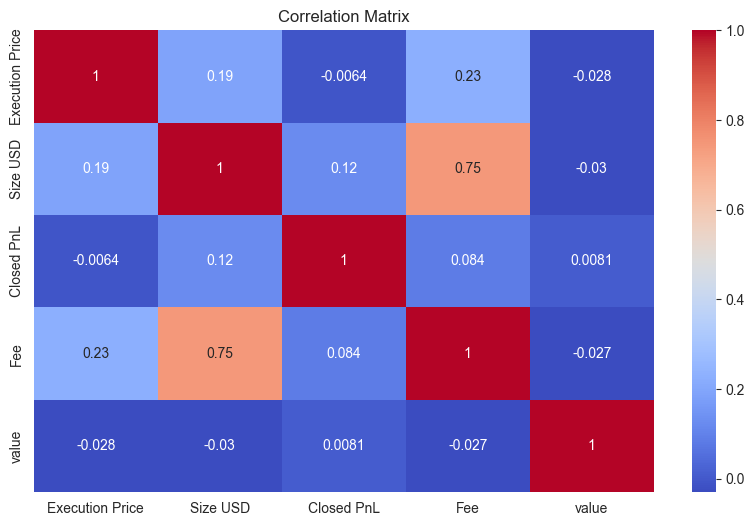

In [72]:
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()